# Jupyter Notebook Code Compilation for Homework Reflection: Weeks 1-4

# Week 1 Quiz Code

Install missing requirements 

In [ ]:
%pip install scikit-learn
%pip install pandas
%pip install statsmodels
%pip install matplotlib

Import Models Used for Week 1 Coding

In [1]:
import pandas as pd
import numpy as np
import itertools
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import NearestNeighbors

Assessment Content
For questions 1 to 3:

Perform a linear regression to predict Y from X1, X2, and X3. Use the file homework_1.1.csv.

In [7]:
# Load .csv file homework_1.1.csv to answer questions 1-3 in week 1 homework and create dataframe name df_X1:

df_X1 = pd.read_csv("homework_1.1.csv")

In [8]:
# Set Up X and y variables from columns present in df_X1 dataframe

X = df_X1[['X1','X2','X3']]
y = df_X1['Y']

Question 1: Which of the following is closest to the coefficient of X1? 

In [4]:
# Create Linear Regression Model

linear_model = LinearRegression()
linear_model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
# Get Model Parameters
intercept = linear_model.intercept_
coefficients = linear_model.coef_

In [11]:
# Separate Coefficients X1, X2, X3 into individual variables

X1_coefficient = coefficients[0]
X2_coefficient = coefficients[1]
X3_coefficient = coefficients[2]

# Print coeffient values
print(f'X1 coefficent: {X1_coefficient}')
print(f'X2 coefficent: {X2_coefficient}')
print(f'X3 coefficent: {X3_coefficient}')

X1 coefficent: 1.007137655075957
X2 coefficent: 1.9645685948713498
X3 coefficent: 2.9754885351434215


In [12]:
# Print only X1 coefficent 

print(f'X1 coefficent: {X1_coefficient}')

X1 coefficent: 1.007137655075957


Question 2: Which Xi has the greatest difference between the amount Y increases for each 1 unit of Xi (fixing the other Xi’s), as opposed to the amount that Y increases for each 1 unit of Xi in the dataset, on average (not fixing the other Xis)? Hint: for the former, you'll have to regress Y on Xi alone, while for the latter, you'll have to regress Y on all three Xis. 

In [13]:
# Calculating the X1, X2 and X3

X1 = df_X1[['X1']]
X1_linear_model = LinearRegression()
X1_linear_model.fit(X1,y)
SX1_coefficient = X1_linear_model.coef_

X2 = df_X1[['X2']]
X2_linear_model = LinearRegression()
X2_linear_model.fit(X2,y)
SX2_coefficient = X2_linear_model.coef_

X3 = df_X1[['X3']]
X3_linear_model = LinearRegression()
X3_linear_model.fit(X3,y)
SX3_coefficient = X3_linear_model.coef_


In [15]:
# Calculate Variance for X1, X2 and X3 coefficients variance

X1_variance = abs(X1_coefficient - SX1_coefficient)
X2_variance = abs(X2_coefficient - SX2_coefficient)
X3_variance = abs(X3_coefficient - SX3_coefficient)


# Print X1, X2 and X3 variance
print(f'X1 variance: {X1_variance}')
print(f'X2 variance: {X2_variance}')
print(f'X3 variance: {X3_variance}')

X1 variance: [0.83462344]
X2 variance: [2.11904398]
X3 variance: [0.12155267]


Question 3: When regressing Y on all Xis together, which coefficient is most significant, considering the t-statistic as a measure of significance? 

In [16]:
# Get the t-statistic for X1,X2,X3 values

X = sm.add_constant(X)
t_model = sm.OLS(y, X).fit()

In [17]:
# Print the t-statistics values
print(t_model.tvalues)

const      0.166181
X1        60.984011
X2        53.283212
X3       196.645240
dtype: float64


Assessment Content
For Question 4 and 5:


Use NearestNeighbors to match data based on variables Z, given the file homework_1.2.csv.
Pick the best match in X = 0 corresponding to each X = 1. Use the Z values to perform the match: a good match with X = 1 is the item whose Z value is closest to the given sample's Z value with X = 0. I suggest using sklearn's NearestNeighbors to do this, but there are many ways to do it.  

In [18]:
# Load .csv file homework_1.2.csv to answer questions 4-5 in week 1 homework and create dataframe named df_2:

df_2 = pd.read_csv("homework_1.2.csv")

Question 4: What is the distance of the farthest match in this set? 

In [19]:
# Separate Treated (X=1) and Untreated (X=0) Groups

treated_z = df_2[df_2['X'] == 1][['Z']]
control_z = df_2[df_2['X'] == 0][['Z']]

In [20]:
# Set Nearest Neighbors

nearest_neighbor = NearestNeighbors(n_neighbors=1)
nearest_neighbor.fit(control_z)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [21]:
# Find Distance to Treated Groups

distance, indices = nearest_neighbor.kneighbors(treated_z)
max_distance = np.max(distance)

In [22]:
# Display max distance

print(max_distance)

0.2102170871093757


Question 5: What is the effect? (The difference between the average Y value for X = 0 values vs. the average Y value for X = 1, where the X = 0 sample has the best match for each X = 1 value). So we use the matched sample of X = 0 and the full sample of X = 1.

In [23]:
# Get positions of matched Control Groups

control_df = df_2[df_2['X'] == 0]
matched_control_y = control_df.iloc[indices.flatten()]['Y'].values

treated_y = df_2[df_2['X'] == 1]['Y'].values

In [24]:
# Calculate Averages

average_y_treated = np.mean(treated_y)
average_y_matched_control = np.mean(matched_control_y)


In [25]:
# Calculate the Difference

effect = average_y_treated - average_y_matched_control

In [26]:
# Display Difference

print(effect)

0.5433600652185839


Assessment Content
For questions 6 and 7:

Use NearestNeighbors to match data based on variables Z, given the file homework_1.2.csv. 
Try approach B: Pick all of the matches in X = 0 that are within a distance 0.2 of each X = 1. Duplicates are okay, in case a given sample with X = 0 is a good match for multiple items with X = 1. 

In [27]:
# Load .csv file homework_1.2.csv to answer questions 6-7 in week 1 homework and create dataframe named df_3:

df_3 = pd.read_csv("homework_1.2.csv")

Question 6: How many duplicates do you end up with? (Count all but the first duplicate in each group. One way to do this is to use radius_neighbors.)

In [28]:
# Separate Treated (X=1) and Untreated (X=0) Groups

treated_z2 = df_3[df_3['X'] == 1].copy().reset_index(drop=True)
control_z2 = df_3[df_3['X'] == 0].copy().reset_index(drop=True)

In [29]:
# Set Nearest Radius

nearest_radius = NearestNeighbors(radius=0.2)
nearest_radius.fit(control_z2[['Z']])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",0.2
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [30]:
# Find Distance to Treated Groups

distance, indices = nearest_radius.radius_neighbors(treated_z2[['Z']])

In [32]:
# Matched Indices

all_matched_indices = [idx for sublist in indices for idx in sublist]

matched_controls = control_z2.iloc[all_matched_indices]


In [33]:
# Calculate the number of duplicates
# Duplicates = Total matches - Unique units matched
total_matches = len(all_matched_indices)
unique_matches = len(set(all_matched_indices))
duplicates_count = total_matches - unique_matches

In [35]:
# Print Duplicate Count

print(f'Duplicate Count: {duplicates_count}')

Duplicate Count: 685


Question 7: What is the effect? (Note: to compute the effect, you should take the mean of the Y values in each neighbor group, then average the Y for each group.)

In [36]:
# Take the mean of the Y values in each neighbor group
neighbor_group_means = []
matched_treated_Y = []

for i, sublist in enumerate(indices):
    if len(sublist) > 0:  # Only if the treated unit found neighbors within the radius
        group_mean = control_z2.iloc[sublist]["Y"].mean()
        neighbor_group_means.append(group_mean)
        matched_treated_Y.append(treated_z2.iloc[i]["Y"])



In [37]:
# Finding the Average the Y for each group and compute the effect for control and SCENARIO A and B

# Average for the control group (average of the neighbor group means)
control_group_avg = np.mean(neighbor_group_means)

# SCENARIO A: Average only the treated units that found matches
treated_group_avg_A = np.mean(matched_treated_Y)
effect_A = treated_group_avg_A - control_group_avg

# SCENARIO B: Average all treated units regardless of matches
treated_group_avg_B = treated_z2["Y"].mean()
effect_B = treated_group_avg_B - control_group_avg


In [38]:
# Print effect values for control and SCENARIO A and B

print(f"Control group average (neighbor means): {control_group_avg:.5f}")
print(f"Scenario A Effect (matched only): {effect_A:.5f}")
print(f"Scenario B Effect (all treated): {effect_B:.5f}")

Control group average (neighbor means): 0.54118
Scenario A Effect (matched only): 0.56885
Scenario B Effect (all treated): 0.58441


# Week 2 Quiz Code

Assessment Content
For questions 1 and 2: 

Do a regression to estimate the fixed effect of each group. We assume that there is one single linear coefficient for all the data, plus the fixed effect of each group. Use the file homework_2.1.csv.  The variables G1, G2, and G3 are the outcomes and the time is the treatment.

Import Models Used for Week 2 Coding

In [17]:
import pandas as pd
import numpy as np
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import NearestNeighbors
from scipy.stats import skew

In [2]:
# Load .csv file homework_2.1.csv to answer questions 1-2 in week 2 homework and create dataframe named df_X2:

df_X2 = pd.read_csv("homework_2.1.csv")

Question 1: Which of these is closest to being the coefficient of group 1? 

In [4]:
# Run model regression for Group 1
model = smf.ols('G1 ~ time', data=df_X2).fit()


In [ ]:
# Print the coefficient rounded to 5 decimal places
print("Group 1 Time Coefficient:", round(model.params['time'], 5))

Group 1 Time Coefficient: 0.0085


Question 2: Which of these is closest to being the common linear coefficient for all groups?

In [6]:
# Reshape the DataFrame and rearranges 'G1', 'G2', and 'G3' columns into a single column named 'group' to find 
# their corresponding values into a single column named 'outcome'

df_long = pd.melt(df_X2, id_vars=['time'], value_vars=['G1', 'G2', 'G3'], var_name='group', value_name='outcome')


In [7]:
# Fit an Ordinary Least Squares (OLS) linear regression model
# Test with an explicit intercept 

model_with_intercept = smf.ols('outcome ~ time + C(group)', data=df_long).fit()

In [8]:
# Print model intercept summary

print(model_with_intercept.summary())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     44.55
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           8.72e-24
Time:                        20:52:56   Log-Likelihood:                -216.89
No. Observations:                 300   AIC:                             441.8
Df Residuals:                     296   BIC:                             456.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0786      0.071      1.

Assessment Content
For questions 3-5:

Given a data set, create a bootstrap simulation to try different possibilities. 
Use the file homework_2.2.csv 

In [9]:
# Load .csv file homework_2.2.csv to answer questions 3-5 in week 2 homework and create dataframe named df_X22:

df_X22 = pd.read_csv('homework_2.2.csv')

Question 3: If we were to measure the effect of the treatment simply by subtracting the outcomes of the treated vs. untreated population, which of these is closest to the mean effect? (This is not the recommended way of measuring the mean effect when there are confounders!) 

In [10]:
# Calculate the mean outcome for treated (X = 1) and untreated (X = 0) populations

mean_treated = df_X22[df_X22['X'] == 1]['Y'].mean()
mean_untreated = df_X22[df_X22['X'] == 0]['Y'].mean()

In [11]:
# Calculate the simple treatment effect

mean_effect = mean_treated - mean_untreated

In [12]:
# Print outcomes

print(f"Mean outcome for treated (X=1): {mean_treated:.4f}")
print(f"Mean outcome for untreated (X=0): {mean_untreated:.4f}")
print(f"Simple Mean Effect: {mean_effect:.4f}")

Mean outcome for treated (X=1): 7.8428
Mean outcome for untreated (X=0): 4.9220
Simple Mean Effect: 2.9207


Question 4: If we were to use bootstrap sampling to measure the variance of that effect, again finding the effect using the non-recommended approach, which of these is closest to that variance?

In [13]:
# Set a random seed for reproducibility
np.random.seed(42)


In [14]:
# Number of bootstrap replications
B = 10000
boot_effects = []

for _ in range(B):
    # Sample rows with replacement
    boot_df = df_X22.sample(frac=1.0, replace=True)
    
    # Calculate the simple treatment effect for the bootstrap sample
    mean_treated = boot_df[boot_df['X'] == 1]['Y'].mean()
    mean_untreated = boot_df[boot_df['X'] == 0]['Y'].mean()
    
    boot_effects.append(mean_treated - mean_untreated)


In [15]:
# Calculate the variance of the bootstrap treatment effects

bootstrap_variance = np.var(boot_effects, ddof=1)

In [16]:
# Print bootstrap value

print(f"Bootstrap Variance: {bootstrap_variance:.4f}")

Bootstrap Variance: 0.0326


Question 5: if we ran a linear regression (with intercept) to measure the effect, which of these is closest to the skewness of the effect measured? (Look up skewness online. You can use scipy.stats.skew to compute the skewness of a list of numbers.) 

In [18]:
# Set random seed for reproducibility

np.random.seed(42)

In [19]:
# Number of bootstrap replications

B = 5000
boot_effects = []

for _ in range(B):
    # Sample rows with replacement
    boot_df = df_X22.sample(frac=1.0, replace=True)
    
    # Reshape variables for linear regression
    X_boot = boot_df[['X']]
    y_boot = boot_df['Y']
    
    # Fit linear regression model with intercept
    model = LinearRegression().fit(X_boot, y_boot)
    
    # The coefficient of X is the measured treatment effect
    boot_effects.append(model.coef_[0])


In [20]:
# Compute the skewness of the measured effects

effect_skewness = skew(boot_effects)

In [21]:
# Print Skewness Value

print(f"Skewness of the effect measured: {effect_skewness:.4f}")

Skewness of the effect measured: 0.0415


# Week 3 Quiz Code

Assessment Content
For questions 1 and 2: 

Given a dataset with time series data containing an event, use a linear regression to test whether there was a discontinuity in the data at the event. Consider the possibility, first, of a discontinuity only in the value of the variable but not the derivative. Then consider that there may be a discontinuity in the first derivative (the slope).  
Use the file homework_3.1.csv. 

Import Models Used for Week 3 Coding

In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [23]:
# Load .csv file homework_3.1.csv to answer questions 1-2 in week 3 homework and create dataframe named df_X3:

df_X3 = pd.read_csv("homework_3.1.csv")

Question 1: Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the value at the event (at time = 50)? 

In [24]:
# Create the regression variables
df_X3['D'] = (df_X3['time'] >= 50).astype(int)
df_X3['time_centered'] = df_X3['time'] - 50
df_X3['D_time_centered'] = df_X3['D'] * df_X3['time_centered']


In [25]:
# Run regressions for each value column and print results

for val in ['value1', 'value2', 'value3']:
    print(f"\n=================== Analysis for {val} ===================")
    
    # Model 1: Discontinuity in value only
    X1 = sm.add_constant(df_X3[['time_centered', 'D']])
    model1 = sm.OLS(df_X3[val], X1).fit()
    print("--- Model 1: Value Discontinuity Only ---")
    print(model1.summary().tables[1])
    
    # Model 2: Value and Slope Discontinuity
    X2 = sm.add_constant(df_X3[['time_centered', 'D', 'D_time_centered']])
    model2 = sm.OLS(df_X3[val], X2).fit()
    print("--- Model 2: Value and Slope Discontinuity ---")
    print(model2.summary().tables[1])


=================== Analysis for value1 ===================
--- Model 1: Value Discontinuity Only ---
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.7488      0.277      6.310      0.000       1.199       2.299
time_centered     0.0439      0.008      5.168      0.000       0.027       0.061
D                 0.8508      0.490      1.737      0.086      -0.121       1.823
--- Model 2: Value and Slope Discontinuity ---
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4059      0.274      1.479      0.142      -0.139       0.951
time_centered      -0.0088      0.009     -0.940      0.349      -0.027       0.010
D                   0.9035      0.382      2.362      0.020       0.144       1.663
D_time_centered     

Question 2: Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the derivative (at time = 50)? 

In [26]:
# Create the features for Interrupted Time Series Analysis

df_X3['D'] = (df_X3['time'] >= 50).astype(int)
df_X3['time_centered'] = df_X3['time'] - 50
df_X3['D_time_centered'] = df_X3['D'] * df_X3['time_centered']

In [27]:
# Add constant for the regression intercept
X = sm.add_constant(df_X3[['time_centered', 'D', 'D_time_centered']])

In [28]:
# Run the regression for each dataset and print the derivative discontinuity metric and print results
for val in ['value1', 'value2', 'value3']:
    model = sm.OLS(df_X3[val], X).fit()
    coef = model.params['D_time_centered']
    t_stat = model.tvalues['D_time_centered']
    p_val = model.pvalues['D_time_centered']
    
    print(f"{val}: Slope Change (Beta_3) = {coef:.4f}, t-statistic = {t_stat:.3f}, p-value = {p_val:.5f}")

value1: Slope Change (Beta_3) = 0.1053, t-statistic = 7.951, p-value = 0.00000
value2: Slope Change (Beta_3) = 0.0369, t-statistic = 2.567, p-value = 0.01181
value3: Slope Change (Beta_3) = 0.0507, t-statistic = 3.857, p-value = 0.00021


Assessment Content
For questions 3 to 5:  

Given a dataset with treatment and control data having “before” and “after” parts, apply a differences-in-differences regression.  
Use homework_3.2.a.csv and homework_3.2.b.csv. 

In [30]:
# Load .csv files homework_3.2.a.csv and homework_3.2.b.csv to answer questions 3-5 in week 3 homework and create dataframe named df_a and df_b:

df_a = pd.read_csv('homework_3.2.a.csv')
df_b = pd.read_csv('homework_3.2.b.csv')

Question 3: Which dataset likely has the largest treatment effect, assuming that the treatment and control groups have parallel trends? 

In [31]:
# Estimate DiD model for Dataset A (homework_3.2.a.csv)
model_a = smf.ols('outcome1 ~ group1 + time1 + group1:time1', data=df_a).fit()

# Estimate DiD model for Dataset B (homework_3.2.b.csv)
model_b = smf.ols('outcome2 ~ group2 + time2 + group2:time2', data=df_b).fit()

In [32]:
# Print Dataset A results
print("=== Dataset A (homework_3.2.a.csv) ===")
print(model_a.summary().tables[1])

# Print Dataset B results
print("\n=== Dataset B (homework_3.2.b.csv) ===")
print(model_b.summary().tables[1])

=== Dataset A (homework_3.2.a.csv) ===
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0258      0.031     -0.829      0.408      -0.087       0.035
group1           1.9863      0.044     44.928      0.000       1.900       2.073
time1            1.4272      0.044     32.315      0.000       1.341       1.514
group1:time1     0.6858      0.063     10.970      0.000       0.563       0.809

=== Dataset B (homework_3.2.b.csv) ===
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1021      0.073      1.392      0.164      -0.042       0.246
group2           1.8477      0.104     17.770      0.000       1.644       2.052
time2            1.2655      0.104     12.183      0.000       1.062       1.469
group2:time2     1.3499      0

Question 4: Using the standard errors for regression, which dataset has the most statistically significant (and nonzero) treatment effect? 

In [33]:
# Fit Differences-in-Differences models
model_a = smf.ols('outcome1 ~ group1 + time1 + group1:time1', data=df_a).fit()
model_b = smf.ols('outcome2 ~ group2 + time2 + group2:time2', data=df_b).fit()

In [34]:
# Print Dataset A Results
print("=== Dataset A (homework_3.2.a.csv) ===")
print(f"Treatment Effect Coef : {model_a.params['group1:time1']:.4f}")
print(f"Standard Error        : {model_a.bse['group1:time1']:.4f}")
print(f"t-statistic           : {model_a.tvalues['group1:time1']:.3f}")
print(f"p-value               : {model_a.pvalues['group1:time1']:.5e}")

# Print Dataset B Results
print("\n=== Dataset B (homework_3.2.b.csv) ===")
print(f"Treatment Effect Coef : {model_b.params['group2:time2']:.4f}")
print(f"Standard Error        : {model_b.bse['group2:time2']:.4f}")
print(f"t-statistic           : {model_b.tvalues['group2:time2']:.3f}")
print(f"p-value               : {model_b.pvalues['group2:time2']:.5e}")

=== Dataset A (homework_3.2.a.csv) ===
Treatment Effect Coef : 0.6858
Standard Error        : 0.0625
t-statistic           : 10.970
p-value               : 1.64005e-26

=== Dataset B (homework_3.2.b.csv) ===
Treatment Effect Coef : 1.3499
Standard Error        : 0.1470
t-statistic           : 9.180
p-value               : 2.43244e-19


Question 5: Which of these is closest to the treatment effect for group 2? 

In [35]:
# Fit the Differences-in-Differences regression model
model_b = smf.ols('outcome2 ~ group2 + time2 + group2:time2', data=df_b).fit()

In [36]:
# Print the treatment effect coefficient (interaction term)
treatment_effect = model_b.params['group2:time2']
print(f"Treatment Effect for Group 2: {treatment_effect}")

Treatment Effect for Group 2: 1.349858924679673


# Week 4 Quiz Code

Assessment Content
Task:

Given data about an instrumental variable, find the effect. X is the treatment, W the confounder, Y the outcome, and Z the instrument. Use homework_4.1.csv. 

Import Models Used for Week 4 Coding

In [37]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression

In [38]:
# Load .csv file homework_4.1.csv to answer questions 1-2 in week 4 homework and create dataframe named df_X4:

df_X4 = pd.read_csv("homework_4.1.csv")

Question 1: Did you need to know W to do this? 

Question 2: As in the explanation, try averaging the ﻿Y﻿ difference and ﻿X﻿ difference (over ﻿W﻿ and ﻿Z﻿) in two ways: 

Subtract the average ﻿Y﻿ value for ﻿Z equals 1﻿and ﻿Z equals 0﻿. Subtract the average ﻿X﻿value for ﻿Z equals 1﻿ and ﻿Z equals 0﻿. Divide the two. 
Find the average ﻿Y﻿ value for ﻿Z equals 1﻿and ﻿Z equals 0﻿ for a narrow range of ﻿W﻿. Find the average ﻿X﻿value for ﻿Z equals 1﻿ and ﻿Z equals 0﻿ for the same narrow range of ﻿W﻿. Take the ratio to find the effect. Then average this over all the ranges of ﻿W﻿.


For the first item, the effect is closest to: 

In [39]:
# Using Simple ratio of averages Method
mean_Y_Z1 = df_X4.loc[df_X4['Z']==1, 'Y'].mean()
mean_Y_Z0 = df_X4.loc[df_X4['Z']==0, 'Y'].mean()
mean_X_Z1 = df_X4.loc[df_X4['Z']==1, 'X'].mean()
mean_X_Z0 = df_X4.loc[df_X4['Z']==0, 'X'].mean()

diff_Y = mean_Y_Z1 - mean_Y_Z0
diff_X = mean_X_Z1 - mean_X_Z0
iv_method1 = diff_Y / diff_X

In [40]:
# Using Local ratios averaged over narrow bins of W Method
n_bins = 50
df_X4['W_bin'] = pd.cut(df_X4['W'], bins=n_bins)

local_effects = []
for bin_label, group in df_X4.groupby('W_bin', observed=True):
    g1 = group[group['Z']==1]
    g0 = group[group['Z']==0]
    if len(g1) > 1 and len(g0) > 1:
        dy = g1['Y'].mean() - g0['Y'].mean()
        dx = g1['X'].mean() - g0['X'].mean()
        if abs(dx) > 1e-8:
            local_effects.append(dy / dx)


In [41]:
# Calculate Mean Local Effects

iv_method2 = np.mean(local_effects)

In [42]:
# Print Results for Both Methods analyzed

print(f'iv_method1: {iv_method1}')
print(f'iv_method2: {iv_method2}')


iv_method1: 1.5618587073765746
iv_method2: 1.4848406457567933


Assessment Content
Task: 

Given student data involving test scores (﻿X﻿), a cutoff, and an outcome (Y), which measures whether the students got into college (as in the example in the text), determine whether the math course helps students get into college in each dataset. Use datasets homework_4.2.a and homework_4.2.b. 

In [43]:
# Load .csv files homework_4.2.a.csv and homework_4.2.b.csv to answer questions 3-5 in week 4 homework and create dataframe named df_X4a and df_X4b:

df_X4a = pd.read_csv("homework_4.2.a.csv")
df_X4b = pd.read_csv("homework_4.2.b.csv")

Question 3: In that dataset, is ﻿Y﻿ increasing or decreasing before the cutoff? 

In [44]:
# Setting columns X and Y for both dataframes

df_X4a.columns = ['X', 'Y']
df_X4b.columns = ['X', 'Y']

# Set cutoff value
cutoff = 80

In [45]:
# Analysis behavior before cutoff

for df, name in [(df_X4a, 'A'), (df_X4b, 'B')]:
    below = df[df.X < cutoff]
    above = df[df.X >= cutoff]

    # Trend below cutoff
    slope, intercept, r, p, se = stats.linregress(below.X, below.Y)
    print(f'Dataset {name} slope below cutoff: {slope:.6f}, p={p:.4f}')
    print(f'Direction: {"INCREASING" if slope > 0 else "DECREASING"}')

    # Jump at cutoff
    near_below = df[(df.X >= 75) & (df.X < 80)].Y.mean()
    near_above = df[(df.X >= 80) & (df.X < 85)].Y.mean()
    jump = near_above - near_below
    print(f'Jump at cutoff: {jump:.4f} => course {"HELPS" if jump > 0 else "HURTS"}')

Dataset A slope below cutoff: 0.000224, p=0.5117
Direction: INCREASING
Jump at cutoff: 0.2966 => course HELPS
Dataset B slope below cutoff: 0.010217, p=0.0000
Direction: INCREASING
Jump at cutoff: 0.2386 => course HELPS


Same code was used for Questions 4 and 5

Question 4: Is ﻿Y﻿'s slope higher or lower after the cutoff compared with before? 

Question 5: Given a cutoff score of 80, which dataset seems most likely to involve a nonzero linear term, allowing ﻿Y﻿to relate linearly to ﻿X﻿ before and after the cutoff? 

In [47]:
# Create function to analysis slope behavior

CUTOFF = 80

def rdd_analysis(df, x_col, y_col, cutoff, name):
    below = df[df[x_col] < cutoff].copy()
    above = df[df[x_col] >= cutoff].copy()

    def slope(data, x, y):
        X = data[[x]].values
        Y = data[y].values
        model = LinearRegression().fit(X, Y)
        return model.coef_[0], model.intercept_

    slope_below, int_below = slope(below, x_col, y_col)
    slope_above, int_above = slope(above, x_col, y_col)

    pred_below = int_below + slope_below * cutoff
    pred_above = int_above + slope_above * cutoff
    jump = pred_above - pred_below

    print(f"Dataset {name}")
    print(f"  Slope below cutoff: {slope_below:.6f}")
    print(f"  Slope above cutoff: {slope_above:.6f}")
    print(f"  Jump at cutoff:     {jump:.4f}")
    print(f"  Course effect:      {'HELPS' if jump > 0 else 'NO EFFECT'}")
    print(f"  Slope after is:     {'HIGHER' if slope_above > slope_below else 'LOWER'}")


In [48]:
# Print dataframe df_X4a analysis
rdd_analysis(df_X4a, 'X',  'Y',  CUTOFF, 'A')

Dataset A
  Slope below cutoff: 0.000224
  Slope above cutoff: 0.000161
  Jump at cutoff:     0.2958
  Course effect:      HELPS
  Slope after is:     LOWER


In [49]:
# Print dataframe df_X4b analysis
rdd_analysis(df_X4b, 'X', 'Y', CUTOFF, 'B')

Dataset B
  Slope below cutoff: 0.010217
  Slope above cutoff: 0.005009
  Jump at cutoff:     0.1971
  Course effect:      HELPS
  Slope after is:     LOWER


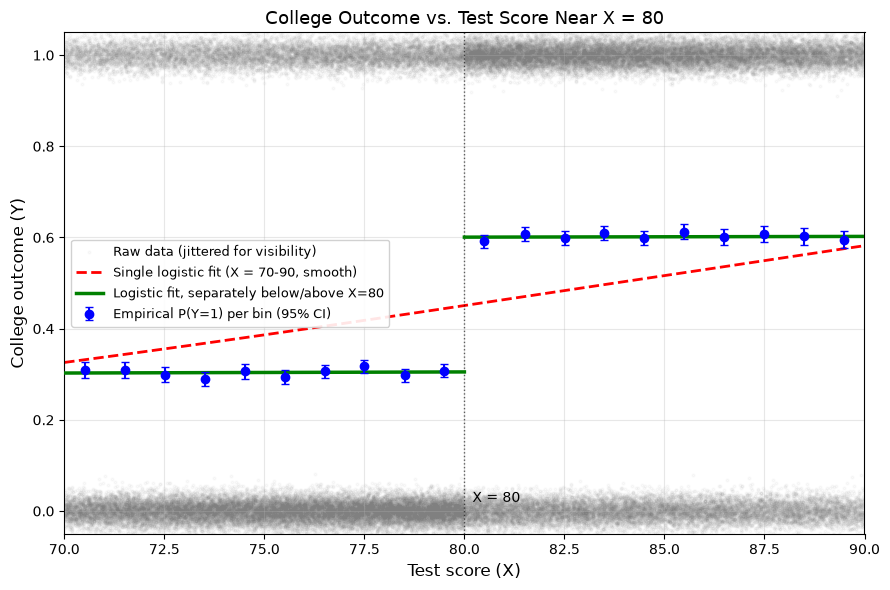

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
 
# Load data
df = pd.read_csv("homework_4.2.a.csv")
X_all = df[['X']].values
y_all = df['Y'].values
 
# Fit logistic regression on the FULL dataset (the "naive" smooth fit)
model = LogisticRegression()
model.fit(X_all, y_all)
 
# Window of interest around X = 80
lo, hi = 70, 90
mask = (df['X'] >= lo) & (df['X'] <= hi)
dfw = df[mask].copy()
 
# Also fit SEPARATE logistic regressions on either side of the X=80 cutoff,
# since the data show a sharp jump there that one smooth curve can't capture
left = df[df['X'] < 80]
right = df[df['X'] >= 80]
model_left = LogisticRegression().fit(left[['X']].values, left['Y'].values)
model_right = LogisticRegression().fit(right[['X']].values, right['Y'].values)
 
# --- Binned empirical probabilities (the "make it readable" trick) ---
n_bins = 20
dfw['bin'] = pd.cut(dfw['X'], bins=n_bins)
binned = dfw.groupby('bin', observed=True).agg(
    x_mean=('X', 'mean'),
    y_mean=('Y', 'mean'),
    n=('Y', 'size')
).reset_index()
 
# Standard error of the binned proportion (for error bars)
binned['se'] = np.sqrt(binned['y_mean'] * (1 - binned['y_mean']) / binned['n'])
 
# --- Logistic regression curve(s) over the window ---
x_curve = np.linspace(lo, hi, 300).reshape(-1, 1)
y_curve_global = model.predict_proba(x_curve)[:, 1]
 
x_curve_left = np.linspace(lo, 80, 150).reshape(-1, 1)
x_curve_right = np.linspace(80, hi, 150).reshape(-1, 1)
y_curve_left = model_left.predict_proba(x_curve_left)[:, 1]
y_curve_right = model_right.predict_proba(x_curve_right)[:, 1]
 
# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))
 
# Raw 0/1 points, jittered vertically and made very transparent, just for context/density
rng = np.random.default_rng(0)
jitter = rng.normal(0, 0.02, size=len(dfw))
ax.scatter(dfw['X'], dfw['Y'] + jitter, s=4, alpha=0.04, color='gray',
           label='Raw data (jittered for visibility)', zorder=1)
 
# Binned empirical probability with error bars
ax.errorbar(binned['x_mean'], binned['y_mean'], yerr=1.96 * binned['se'],
            fmt='o', color='blue', ecolor='blue', elinewidth=1.5,
            capsize=3, markersize=6, label='Empirical P(Y=1) per bin (95% CI)',
            zorder=4)
 
# Naive single logistic regression fit (smooth, ignores the jump)
ax.plot(x_curve, y_curve_global, color='red', linewidth=2, linestyle='--',
         label='Single logistic fit (X = 70-90, smooth)', zorder=2)
 
# Piecewise logistic fits (left of 80 / right of 80) - captures the jump
ax.plot(x_curve_left, y_curve_left, color='green', linewidth=2.5,
         label='Logistic fit, separately below/above X=80', zorder=3)
ax.plot(x_curve_right, y_curve_right, color='green', linewidth=2.5, zorder=3)
 
# Mark the cutoff
ax.axvline(80, color='black', linewidth=1, linestyle=':', alpha=0.6)
ax.text(80.2, 0.02, 'X = 80', fontsize=10, color='black')
 
ax.set_xlim(lo, hi)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Test score (X)', fontsize=12)
ax.set_ylabel('College outcome (Y)', fontsize=12)
ax.set_title('College Outcome vs. Test Score Near X = 80',
              fontsize=13)
ax.legend(loc='center left', fontsize=9.5, framealpha=0.9)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()